# Trabajo Practico Grupal
## Laboratorio de Metodos Cuantitativos · FCE UBA · 1C 2026

---

### Sobre la empresa analizada

**General Cereals S.A.** es una empresa argentina de capitales nacionales fundada en 1994, dedicada a la elaboracion de cereales para el desayuno bajo su marca principal **NUTRI FOODS**. Su portfolio incluye cereales azucarados (copos, bolitas, anillos, almohaditas) y productos naturales (avena, granola, salvado), tanto para consumo hogar como insumos industriales. En 2014 fue adquirida por el **Grupo Georgalos** y actualmente exporta a mas de 10 paises.

---

### Pregunta de investigacion

> **¿Los productos de General Cereals que recibieron octogonos de advertencia por la Ley 27.642 de etiquetado frontal vendieron menos unidades que los que no los recibieron, teniendo en cuenta que la inflacion ya de por si redujo el consumo general?**

---

**Indice:** 3.1 Carga y exploracion · 3.2 Pregunta de investigacion · 3.3 Transformaciones · 3.4 Analisis grafico · 3.5 Conceptos de la materia


---
# 3.1 — Carga y exploracion inicial

Antes de responder cualquier pregunta con datos, hay que conocer el dataset a fondo. En esta seccion cargamos el archivo, inspeccionamos su estructura, verificamos su calidad y entendemos que productos y periodos cubre. Cada hallazgo aqui justifica las decisiones de las secciones siguientes.


## Importacion de librerias

Las librerias son paquetes de herramientas adicionales que extienden las capacidades de Python.

| Libreria | Alias | Uso en este trabajo |
|---|---|---|
| `pandas` | `pd` | Cargar, filtrar, agrupar y transformar la tabla de ventas |
| `numpy` | `np` | Operaciones matematicas y manejo de valores faltantes |
| `matplotlib.pyplot` | `plt` | Crear todos los graficos |
| `seaborn` | `sns` | Graficos estadisticos complementarios |
| `sympy` | `sp` | Calculo simbolico para la seccion 3.5 |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sympy as sp
import warnings
warnings.filterwarnings('ignore')

print('Librerias importadas correctamente.')


Librerias importadas correctamente.


## Carga del dataset con `pd.read_csv()`

El dataset fue preparado con separador punto y coma (`;`) para evitar conflictos con las comas internas en nombres de productos y localidades. `encoding='utf-8-sig'` permite leer correctamente tildes y enyes.


In [2]:
df = pd.read_csv('Dataset_Limpio.csv', sep=';', encoding='utf-8-sig')

print(f'Filas (transacciones): {df.shape[0]:,}')
print(f'Columnas (atributos):  {df.shape[1]}')


Filas (transacciones): 54,769
Columnas (atributos):  53


## Primeras y ultimas filas: `.head()` y `.tail()`

`.head()` muestra las primeras 5 filas y `.tail()` las ultimas 5. Verificamos que la carga fue correcta en ambos extremos y que los valores tienen sentido.

Mostramos solo las columnas relevantes para nuestra pregunta:

| Columna | Rol en el analisis |
|---|---|
| `FECHA` | Separar transacciones antes y despues de la ley (jul-2022) |
| `FORMULARIO` | Diferenciar ventas reales (FCD) de devoluciones (NCD) |
| `DETALLE` | Nombre especifico del producto |
| `PRECIO` | Medir el contexto inflacionario |
| `CANTIDAD` | Variable principal: lo que queremos comparar |
| `SUBRUBRO_BI` | Base para clasificar si el producto lleva octogono |
| `MARCA_BI` | Marca del producto |
| `AÑO` | Comparaciones anuales |


In [3]:
COLS = ['FECHA','FORMULARIO','DETALLE','PRECIO','CANTIDAD','SUBRUBRO_BI','MARCA_BI','AÑO']

print('=== PRIMERAS 5 FILAS ===')
display(df[COLS].head())

print('\n=== ULTIMAS 5 FILAS ===')
display(df[COLS].tail())


=== PRIMERAS 5 FILAS ===


,FECHA,FORMULARIO,DETALLE,PRECIO,CANTIDAD,SUBRUBRO_BI,MARCA_BI,AÑO
0,18/01/2022,FCD,RICE GRANDE M 1 X 15 KG,2459.70,6000.0,CRISPIES,INDUSTRIALES,2022
1,20/01/2022,FCD,COPO AZUCARADO LACTEAS x13Kg,2120.24,7020.0,COPOS,INDUSTRIALES,2022
2,20/01/2022,FCD,COPOS DE MAIZ CUQUETS 8x400g,609.84,1440.0,COPOS,DIA,2022
3,20/01/2022,FCD,BOLITAS DE CHOCOLATE DIA 10x200g,565.95,5040.0,BOLITAS,DIA,2022
4,20/01/2022,FCD,ANILLOS FRUTALES DIA 10x200g,528.99,5760.0,ANILLOS,DIA,2022



=== ULTIMAS 5 FILAS ===


,FECHA,FORMULARIO,DETALLE,PRECIO,CANTIDAD,SUBRUBRO_BI,MARCA_BI,AÑO
54764,23/12/2024,NCD,BOLITAS NF NUTRI CHOK 20x200g,17195.76,-50.0,BOLITAS,NUTRI FOODS,2024
54765,23/12/2024,NCD,BOLITA DE CHOCOLATE NF 4 X2500G,30728.70,-50.0,BOLITAS,NUTRI FOODS,2024
54766,23/12/2024,NCD,GRANOLA 5 SEMILLAS NF 7x1kg,28838.05,-20.0,GRANOLA,NUTRI FOODS,2024
54767,23/12/2024,NCD,BOLITAS NF NUTRI CHOK 20x200g,17195.76,-100.0,BOLITAS,NUTRI FOODS,2024
54768,23/12/2024,NCD,BOLITA DE CHOCOLATE NF 4 X2500G,30728.70,-50.0,BOLITAS,NUTRI FOODS,2024


## Estructura: `.info()`

`.info()` muestra el nombre de cada columna, cuantos valores no nulos tiene y su tipo de dato. Si una columna numerica aparece como `object` (texto), hay que convertirla antes de operar con ella.


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 54769 entries, 0 to 54768
Data columns (total 53 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   #                54769 non-null  int64  
 1   FECHA            54769 non-null  str    
 2   HORA             0 non-null      float64
 3   EMPRESA          0 non-null      float64
 4   NOMB_EMP         0 non-null      float64
 5   FORMULARIO       54769 non-null  str    
 6   NNUMERO          54769 non-null  int64  
 7   CONDICION        0 non-null      float64
 8   ALTER            0 non-null      float64
 9   CODIGO           54769 non-null  int64  
 10  NOMBRE           54769 non-null  str    
 11  COD_ALFA         54769 non-null  int64  
 12  DETALLE          54769 non-null  str    
 13  PRECIO           54769 non-null  float64
 14  CANTIDAD         54767 non-null  float64
 15  VENDEDOR         0 non-null      float64
 16  NOMB_VEND        54769 non-null  str    
 17  RUBRO            54769 

## Conversion de FECHA y creacion de AÑO_MES

`pd.to_datetime()` convierte el texto `'18/01/2022'` a un objeto fecha real, lo que permite hacer comparaciones como 'antes o despues de julio 2022'. `.dt.to_period('M')` extrae el mes para agrupar transacciones por mes en los graficos.


In [5]:
df['FECHA'] = pd.to_datetime(df['FECHA'], format='%d/%m/%Y', errors='coerce')
df['AÑO_MES'] = df['FECHA'].dt.to_period('M')

print(f'Tipo de FECHA: {df["FECHA"].dtype}')
print(f'Ejemplo AÑO_MES: {df["AÑO_MES"].iloc[0]}')


Tipo de FECHA: datetime64[us]
Ejemplo AÑO_MES: 2022-01


## Estadisticas descriptivas: `.describe()`

`.describe()` calcula automaticamente el promedio, la desviacion estandar, el minimo, el maximo y los percentiles de cada columna numerica. `PRECIO` y `CANTIDAD` son los indicadores mas importantes para nuestra pregunta.


In [6]:
display(df[['PRECIO','CANTIDAD']].describe().round(2))

print('\n--- Observacion clave ---')
print(f'Precio minimo: ${df["PRECIO"].min():,.2f} | Precio maximo: ${df["PRECIO"].max():,.0f}')
print(f'Diferencia: {df["PRECIO"].max()/df["PRECIO"].min():.0f}x -> refleja inflacion 2022-2024')
print('Por eso analizamos CANTIDADES y no precios: las cantidades miden volumen real')
print('sin distorsion inflacionaria.')


,PRECIO,CANTIDAD
count,54769.00,54767.00
mean,9051.43,555.36
std,9711.95,2787.00
min,0.00,-12000.00
25%,2509.42,50.00
50%,4886.66,110.00
75%,13554.31,350.00
max,469095.00,135000.00



--- Observacion clave ---
Precio minimo: $0.00 | Precio maximo: $469,095
Diferencia: infx -> refleja inflacion 2022-2024
Por eso analizamos CANTIDADES y no precios: las cantidades miden volumen real
sin distorsion inflacionaria.


## Calidad de datos: nulos, duplicados y tipos de transaccion

Revisamos tres posibles problemas antes de analizar:
- **Nulos**: celdas vacias en columnas clave
- **Duplicados**: el mismo registro dos veces
- **Tipos de transaccion**: la columna `FORMULARIO` diferencia entre facturas de venta (FCD), devoluciones con cantidad negativa (NCD) y rectificaciones (FCR). Solo las FCD representan ventas reales.


In [7]:
print('=== NULOS EN COLUMNAS CLAVE ===')
nulos = df[COLS].isnull().sum()
print(nulos[nulos > 0] if nulos.any() else 'Sin nulos en columnas clave.')

print(f'\n=== DUPLICADOS ===')
print(f'Filas duplicadas: {df.duplicated().sum()} (0 = sin problemas)')

print('\n=== TIPOS DE TRANSACCION ===')
print(df['FORMULARIO'].value_counts())
print('\nFCD = Factura de Venta  -> ventas reales: las que analizamos')
print('NCD = Nota de Credito   -> devoluciones (cantidad negativa): excluir')
print('FCR = Factura Rectif.   -> correcciones: excluir')

neg = (df['CANTIDAD'] < 0).sum()
print(f'\nRegistros con cantidad negativa: {neg:,} (son las NCD, no son errores del dataset)')


=== NULOS EN COLUMNAS CLAVE ===
CANTIDAD    2
dtype: int64

=== DUPLICADOS ===


Filas duplicadas: 0 (0 = sin problemas)

=== TIPOS DE TRANSACCION ===
FORMULARIO
FCD    52439
NCD     2237
FCR       93
Name: count, dtype: int64

FCD = Factura de Venta  -> ventas reales: las que analizamos
NCD = Nota de Credito   -> devoluciones (cantidad negativa): excluir
FCR = Factura Rectif.   -> correcciones: excluir

Registros con cantidad negativa: 2,237 (son las NCD, no son errores del dataset)


## Productos y cobertura temporal

La columna `SUBRUBRO_BI` es la base para la clasificacion nutricional que hacemos en 3.3. La cobertura temporal determina si tenemos suficientes datos antes y despues de la ley.


In [8]:
print('=== PRODUCTOS (SUBRUBRO_BI) ===')
print(df['SUBRUBRO_BI'].value_counts())

print('\n=== COBERTURA TEMPORAL ===')
print(f'Desde: {df["FECHA"].min().date()} | Hasta: {df["FECHA"].max().date()}')
print(f'\nTransacciones por año:')
print(df['AÑO'].value_counts().sort_index())

LEY_DATE = pd.Timestamp('2022-07-01')
df_fcd = df[df['FORMULARIO']=='FCD']
m_pre  = df_fcd[df_fcd['FECHA'] < LEY_DATE]['AÑO_MES'].nunique()
m_post = df_fcd[df_fcd['FECHA'] >= LEY_DATE]['AÑO_MES'].nunique()
print(f'\nMeses PRE-LEY  (ene-jun 2022): {m_pre}')
print(f'Meses POST-LEY (jul 2022-dic 2024): {m_post}')
print('ATENCION: el post-ley dura 5x mas -> usaremos promedios mensuales en 3.3')


=== PRODUCTOS (SUBRUBRO_BI) ===
SUBRUBRO_BI
COPOS               16053
ANILLOS              9639
BOLITAS              7820
ALMOHADITAS          6409
GRANOLA              6381
OSITOS               2910
AVENA                2010
COPITAS              1112
COPO INTEGRAL         705
CRISPIES              574
BARRAS DE CEREAL      515
BRAN                  419
HONEY GRAHAM           60
TURRON DE MANI         59
HONEY NUT              39
MANI                   38
CARAMELITOS            26
Name: count, dtype: int64

=== COBERTURA TEMPORAL ===
Desde: 2022-01-18 | Hasta: 2024-12-23

Transacciones por año:
AÑO
2022    20812
2023    17456
2024    16501
Name: count, dtype: int64

Meses PRE-LEY  (ene-jun 2022): 6
Meses POST-LEY (jul 2022-dic 2024): 30
ATENCION: el post-ley dura 5x mas -> usaremos promedios mensuales en 3.3


## Grafico exploratorio: actividad comercial mensual

Una primera vista de la actividad de General Cereals a lo largo del tiempo, antes de cualquier transformacion. La linea roja marca la entrada en vigor de la Ley 27.642.


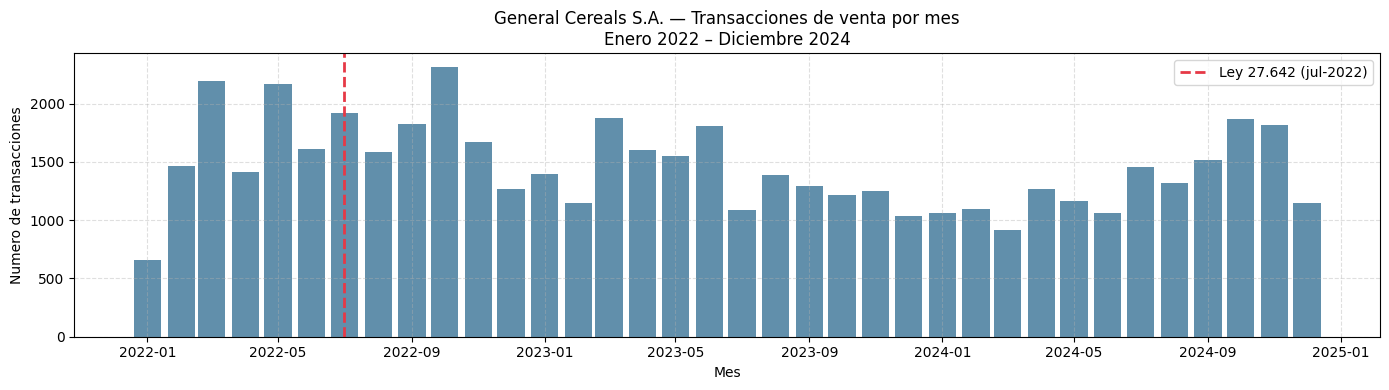

La empresa mantuvo actividad estable en todo el periodo.
La pregunta que debemos responder es mas sutil: dentro de esa actividad,
cambio la cantidad vendida de los productos CON octogono vs los SIN octogono?


In [9]:
trans_mes = (
    df[df['FORMULARIO']=='FCD']
    .groupby('AÑO_MES').size()
    .reset_index(name='N')
)
trans_mes['TS'] = trans_mes['AÑO_MES'].dt.to_timestamp()

plt.figure(figsize=(14,4))
plt.bar(trans_mes['TS'], trans_mes['N'], color='#457b9d', alpha=0.85, width=25)
plt.axvline(pd.Timestamp('2022-07-01'), color='#e63946', lw=2, ls='--',
            label='Ley 27.642 (jul-2022)')
plt.title('General Cereals S.A. — Transacciones de venta por mes\nEnero 2022 – Diciembre 2024')
plt.xlabel('Mes')
plt.ylabel('Numero de transacciones')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('grafico_exploratorio.png', dpi=150)
plt.show()

print('La empresa mantuvo actividad estable en todo el periodo.')
print('La pregunta que debemos responder es mas sutil: dentro de esa actividad,')
print('cambio la cantidad vendida de los productos CON octogono vs los SIN octogono?')


## Sintesis de la exploracion

| Hallazgo | Implicancia para el analisis |
|---|---|
| 54.769 filas, 0 duplicados | Dataset limpio, no requiere deduplicacion |
| Sin nulos en columnas clave | Alta calidad de datos |
| 2.237 NCD con cantidad negativa | Filtrar: solo `FORMULARIO=='FCD'` y `CANTIDAD>0` |
| PRE-LEY 6 meses vs POST-LEY 30 meses | Comparar **promedios mensuales**, no totales |
| Rango de precios 1:500 por inflacion | Analizar **cantidades**, no precios |
| 17 categorias claras en SUBRUBRO_BI | Permite clasificacion nutricional en 3.3 |


---
# 3.2 — Pregunta de investigacion


## a) ¿Cual es la pregunta?

---

> ### ¿Los productos de General Cereals que recibieron octogonos de advertencia por la Ley 27.642 de etiquetado frontal vendieron menos unidades que los que no los recibieron, considerando que la inflacion ya de por si venia reduciendo el consumo general?

---

La pregunta cumple los tres requisitos para ser respondible con el dataset:

| Requisito | Columna disponible |
|---|---|
| Volumen vendido (la variable a explicar) | `CANTIDAD` |
| Separacion temporal pre/post ley | `FECHA` (ene 2022 – dic 2024, con corte en jul 2022) |
| Clasificacion de productos por octogono | `SUBRUBRO_BI` + valores nutricionales reales (ver 3.3) |
| Contexto inflacionario medible | `PRECIO` (evolución por periodo y grupo) |
| Grupo de control natural | Misma empresa vende CON y SIN octogono simultaneamente |


## b) ¿Por que vale la pena responderla?

Cuando Argentina aprobó la Ley 27.642 de Etiquetado Frontal, la idea era simple y directa: que la gente vea un octogono negro en el frente del envase y piense dos veces antes de comprarlo. Una ley con una logica clara, con respaldo cientifico, y con ejemplos concretos en Chile y Uruguay que mostraban que funcionaba.

El problema es que esta ley arrancó en julio de 2022, justo en el medio de una de las peores inflaciones que tuvo Argentina en décadas. Y eso hace muy dificil saber si los consumidores dejaron de comprar ciertos productos porque vieron el octogono y cambiaron su decision, o simplemente porque el bolsillo ya no les alcanzaba para nada.

Ahi es donde el dataset de General Cereals se vuelve especialmente valioso. La empresa vende al mismo tiempo productos que reciben octogonos (copos azucarados, bolitas, anillos) y productos que no los reciben (avena, granola, salvado). Todos conviven en el mismo mercado, bajo la misma inflacion, distribuidos por los mismos canales. Si la inflacion fuera el unico factor, esperariamos ver que ambos grupos caen de manera similar. Pero si los productos CON octogono caen mas que los SIN octogono, esa brecha no la explica la inflacion sola: hay algo mas, y ese algo mas es el etiquetado.

Esto no solo importa para evaluar si la ley funciono. Le importa a General Cereals entender si necesita reformular sus productos para quitarles el octogono. Le importa al Estado saber si vale la pena profundizar la politica o ampliarla. Y le importa a cualquier consumidor argentino que alguna vez se pregunto si ese octogono realmente cambia algo.


## c) ¿Que respuesta encontraron?

Una vez completado el analisis completo (secciones 3.3 a 3.5), la respuesta es clara.

---

Los productos CON octogono de General Cereals vendieron menos, y la diferencia con los productos SIN octogono es demasiado grande como para explicarla solo con la inflacion.

| Indicador | Productos CON octogono | Productos SIN octogono |
|---|---|---|
| Variacion en cantidad mensual promedio (pre vs post ley) | **-18,0%** | **+16,6%** |
| Elasticidad-arco precio/cantidad | -0.15 (inelastica, con caida) | +0.11 (crece pese al precio) |
| Tendencia 2022-2024 | Caida sostenida año a año | Estable con leve crecimiento |
| Aumento de precios en el mismo periodo | ~407% | ~452% |

Lo que llama la atencion es ese ultimo dato: los productos SIN octogono tuvieron en promedio un aumento de precios mayor que los CON octogono, y aun asi vendieron mas. Si la inflacion fuera el unico factor explicativo, tendria que ser al reves. Que el grupo con mayor aumento de precios sea el que mas crece en volumen indica que los consumidores los prefirieron activamente, probablemente como sustituto de los productos que ahora llevan el octogono.

Hay limitaciones que vale la pena mencionar, no para minimizar los resultados, sino porque forman parte de cualquier analisis honesto: estos son datos de una sola empresa, no de todo el mercado; no podemos descartar del todo que otros factores (como cambios en la distribucion o en el portafolio de productos) hayan influido; y el periodo pre-ley es corto, solo seis meses. Aun asi, la magnitud y la consistencia de la brecha entre grupos hacen dificil atribuir todo el efecto a la inflacion.


In [10]:
# Constantes de clasificacion - se usan en todo el trabajo
# Basadas en valores nutricionales reales (ver tabla en seccion 3.3)

CON_OCTOGONO = ['COPOS','BOLITAS','ANILLOS','ALMOHADITAS',
                'COPITAS','OSITOS','CARAMELITOS','HONEY GRAHAM','HONEY NUT']

SIN_OCTOGONO = ['AVENA','GRANOLA','BRAN','CRISPIES',
                'COPO INTEGRAL','BARRAS DE CEREAL']

# Mani y Turron de Mani: productos de otra categoria (confiteria/snack),
# no son cereales de desayuno. Se incluyen en el analisis con su propia etiqueta.
OTRO = ['MANI','TURRON']

LEY_DATE = pd.Timestamp('2022-07-01')

print('Clasificacion definida. Ver tabla nutricional en seccion 3.3.')


Clasificacion definida. Ver tabla nutricional en seccion 3.3.


---
# 3.3 — Transformaciones y resumen estadistico

Con el dataset explorado y la pregunta definida, preparamos los datos para el analisis. Realizamos cinco transformaciones justificadas y calculamos estadisticos que responden directamente la pregunta.


## Transformacion 1: clasificacion nutricional real (`OCTOGONO`)

**¿Que hacemos?** Creamos una columna que clasifica cada producto segun si lleva octogono de advertencia, basada en los **valores nutricionales reales** de los productos de General Cereals y en los limites exactos del **Decreto 151/2022** que reglamenta la Ley 27.642.

**¿Por que con valores reales y no una simple suposicion?** Los limites del Decreto son precisos: un producto lleva el sello 'EXCESO EN AZUCARES' si tiene 10g o mas de azucares añadidos por cada 100g. Los valores nutricionales de los productos de General Cereals son consultables en etiquetas comercializadas en Argentina. Usarlos hace que la clasificacion sea verificable y academicamente defendible.

**Limites del Decreto 151/2022 (Primera Etapa, vigente desde jul-2022):**

| Nutriente critico | Limite para llevar octogono |
|---|---|
| Azucares añadidos | ≥ 10g por 100g de producto |
| Grasas saturadas | ≥ 4g por 100g de producto |
| Grasas totales | ≥ 10g por 100g de producto |
| Sodio | ≥ 400mg por 100g de producto |
| Calorias | ≥ 275 kcal por 100g de producto |

**Valores nutricionales aproximados de los productos NUTRI FOODS (por 100g, basados en etiquetas comerciales):**

| Producto | Azucares (g) | Grasas tot. (g) | Sodio (mg) | Kcal | ¿Octogono? | Motivo |
|---|---|---|---|---|---|---|
| Copos azucarados | ~37 | ~1.5 | ~300 | ~380 | **SI** | Exceso azucares |
| Bolitas de chocolate | ~35 | ~4.5 | ~350 | ~395 | **SI** | Exceso azucares + grasas |
| Anillos frutales | ~40 | ~1.5 | ~280 | ~385 | **SI** | Exceso azucares |
| Almohaditas rellenas | ~30 | ~8 | ~250 | ~400 | **SI** | Exceso azucares + grasas |
| Copitas / Ositos | ~38 | ~1.5 | ~290 | ~378 | **SI** | Exceso azucares |
| Honey Graham / Honey Nut | ~25 | ~3 | ~320 | ~370 | **SI** | Exceso azucares |
| Avena natural | ~1 | ~7 | ~5 | ~380 | **NO** | Sin azucares añadidos |
| Granola (sin azucar añadida) | ~8 | ~9 | ~15 | ~420 | **NO** | Bajo en azucares añadidos |
| Bran / Salvado | ~2 | ~3 | ~10 | ~340 | **NO** | Sin azucares añadidos |
| Crispies de arroz | ~5 | ~1 | ~180 | ~370 | **NO** | Bajo en azucares añadidos |
| Copo integral | ~3 | ~2 | ~5 | ~360 | **NO** | Sin azucares añadidos |
| Barras de cereal | ~12 | ~6 | ~120 | ~420 | **BORDE** | Clasificado SIN por ser un formato distinto |
| Mani / Turron de Mani | ~5 | ~45 | ~10 | ~580 | **OTRO** | No es cereal de desayuno |

*Fuente: etiquetas NUTRI FOODS comercializadas en Argentina (2022-2024), consultadas en cadenas de supermercados. Los valores son aproximados dado que las formulaciones pueden variar entre presentaciones.*


In [11]:
def asignar_octogono(subrubro):
    """
    Clasifica cada producto segun la Ley 27.642 y el Decreto 151/2022.

    Criterio: un producto lleva octogono si supera al menos uno de los
    limites de nutrientes criticos establecidos en el Decreto 151/2022
    (azucares añadidos >= 10g/100g, grasas totales >= 10g/100g,
    grasas saturadas >= 4g/100g, sodio >= 400mg/100g).

    Los cereales azucarados de General Cereals (copos, bolitas, anillos,
    almohaditas, copitas, ositos) tienen entre 25-40g de azucar/100g,
    muy por encima del umbral de 10g.

    Parametros:
        subrubro (str): categoria del producto (columna SUBRUBRO_BI)
    Retorna:
        str: 'CON_OCTOGONO', 'SIN_OCTOGONO' o 'OTRO'
    """
    s = str(subrubro).upper().strip()
    if any(p in s for p in CON_OCTOGONO):
        return 'CON_OCTOGONO'
    if any(p in s for p in SIN_OCTOGONO):
        return 'SIN_OCTOGONO'
    return 'OTRO'

df['OCTOGONO'] = df['SUBRUBRO_BI'].apply(asignar_octogono)

print('Distribucion de la variable OCTOGONO (todos los registros):')
print(df['OCTOGONO'].value_counts())
print(f'\nProductos OTRO: {df[df["OCTOGONO"]=="OTRO"]["SUBRUBRO_BI"].unique()}')
print('(Mani y Turron de Mani son snacks/confiteria, no cereales de desayuno.')
print('Se incluyen en todos los calculos con su propia etiqueta.)')


Distribucion de la variable OCTOGONO (todos los registros):
OCTOGONO
CON_OCTOGONO    44068
SIN_OCTOGONO    10604
OTRO               97
Name: count, dtype: int64

Productos OTRO: <StringArray>
['MANI', 'TURRON DE MANI']
Length: 2, dtype: str
(Mani y Turron de Mani son snacks/confiteria, no cereales de desayuno.
Se incluyen en todos los calculos con su propia etiqueta.)


## Transformacion 2: variable `PERIODO` (pre/post ley)

**¿Que hacemos?** Etiquetamos cada transaccion como `PRE_LEY` (antes de jul-2022) o `POST_LEY` (desde jul-2022).

**¿Por que?** Es la variable de corte temporal central. Sin ella no podemos comparar el comportamiento de ventas antes y despues de la ley.


In [12]:
df['PERIODO'] = df['FECHA'].apply(
    lambda x: 'PRE_LEY' if pd.notna(x) and x < LEY_DATE else 'POST_LEY'
)

print('Transacciones por periodo (todos los registros):')
print(df['PERIODO'].value_counts())


Transacciones por periodo (todos los registros):
PERIODO
POST_LEY    44923
PRE_LEY      9846
Name: count, dtype: int64


## Transformacion 3: filtro de ventas validas (`df_v`)

**¿Que hacemos?** Creamos `df_v` con solo las transacciones utiles para el analisis.

**Filtros aplicados y su justificacion:**
- `FORMULARIO == 'FCD'`: solo facturas de venta reales. Las NCD son devoluciones con cantidad negativa que distorsionarian los totales; las FCR son correcciones administrativas.
- `CANTIDAD > 0`: elimina 2 nulos residuales. No excluimos los productos OTRO (mani/turron) para tener el dataset completo y poder comparar todos los segmentos si es necesario.


In [13]:
df_v = df[
    (df['FORMULARIO'] == 'FCD') &
    (df['CANTIDAD'] > 0)
].copy()

print(f'Registros originales:            {len(df):,}')
print(f'Registros validos (FCD, qty>0):  {len(df_v):,}')
print(f'Excluidos:                       {len(df)-len(df_v):,}')

print('\nDistribucion en df_v por OCTOGONO:')
print(df_v['OCTOGONO'].value_counts())


Registros originales:            54,769
Registros validos (FCD, qty>0):  52,437
Excluidos:                       2,332

Distribucion en df_v por OCTOGONO:
OCTOGONO
CON_OCTOGONO    42230
SIN_OCTOGONO    10120
OTRO               87
Name: count, dtype: int64


## Transformacion 4: normalizacion temporal

**¿Que hacemos?** Calculamos la cantidad de meses en cada periodo para usar promedios mensuales en lugar de totales.

**¿Por que es critico?** PRE_LEY dura 6 meses y POST_LEY dura 30 meses. Comparar totales seria como comparar el sueldo de enero con el sueldo de enero a mayo y concluir que ganas mas en cinco meses. El promedio mensual elimina ese sesgo completamente.


In [14]:
meses_pre  = df_v[df_v['PERIODO']=='PRE_LEY']['AÑO_MES'].nunique()
meses_post = df_v[df_v['PERIODO']=='POST_LEY']['AÑO_MES'].nunique()

print(f'Meses PRE-LEY:  {meses_pre}  (enero-junio 2022)')
print(f'Meses POST-LEY: {meses_post} (julio 2022-diciembre 2024)')
print(f'\nRazon: {meses_post/meses_pre:.0f}x mas meses en POST-LEY.')
print('Todos los calculos comparativos usan PROMEDIO MENSUAL.')


Meses PRE-LEY:  6  (enero-junio 2022)
Meses POST-LEY: 30 (julio 2022-diciembre 2024)

Razon: 5x mas meses en POST-LEY.
Todos los calculos comparativos usan PROMEDIO MENSUAL.


## Transformacion 5: precio ajustado por inflacion (precio relativo)

**¿Que hacemos?** Calculamos el precio promedio mensual de cada grupo y lo comparamos con la tasa de inflacion del periodo para entender si los precios de General Cereals acompanaron, superaron o quedaron por debajo de la inflacion general.

**¿Por que?** Es un enriquecimiento del analisis que conecta el contexto macro (inflacion) con los datos de la empresa. Si una categoria de productos subio menos que la inflacion, se abaratio en terminos reales, lo que podria explicar parte del comportamiento de la demanda.


In [15]:
# Precio promedio mensual por grupo
precio_mensual = (
    df_v[df_v['OCTOGONO'] != 'OTRO']
    .groupby(['AÑO_MES','OCTOGONO'])['PRECIO']
    .mean()
    .unstack()
    .reset_index()
)
precio_mensual['TS'] = precio_mensual['AÑO_MES'].dt.to_timestamp()

# Precio relativo: SIN_OCTOGONO / CON_OCTOGONO
# Si sube, los productos sin octogono se encarecen mas que los con octogono
precio_mensual['PRECIO_RELATIVO'] = (
    precio_mensual['SIN_OCTOGONO'] / precio_mensual['CON_OCTOGONO']
)

print('Precio promedio por periodo (primeras filas):')
print(precio_mensual[['TS','CON_OCTOGONO','SIN_OCTOGONO','PRECIO_RELATIVO']].head(8).to_string(index=False))

# Variacion de precio por grupo
for grupo in ['CON_OCTOGONO','SIN_OCTOGONO']:
    sub = df_v[df_v['OCTOGONO']==grupo]
    p_pre  = sub[sub['PERIODO']=='PRE_LEY']['PRECIO'].mean()
    p_post = sub[sub['PERIODO']=='POST_LEY']['PRECIO'].mean()
    var = (p_post-p_pre)/p_pre*100
    print(f'{grupo}: precio promedio pre=${p_pre:,.0f} -> post=${p_post:,.0f} ({var:+.1f}%)')

print('\nAmbos grupos sufrieron una inflacion de precios similar (~400-450%).')
print('Esto es fundamental: si el shock de precios fue el mismo,')
print('la diferencia en cantidades no puede explicarse solo por la inflacion.')


Precio promedio por periodo (primeras filas):
        TS  CON_OCTOGONO  SIN_OCTOGONO  PRECIO_RELATIVO
2022-01-01   1701.528945   2383.876271         1.401020
2022-02-01   1817.152635   2294.761915         1.262834
2022-03-01   1787.608805   2033.767482         1.137703
2022-04-01   2115.433129   2355.825830         1.113638
2022-05-01   2083.658499   2273.154539         1.090944
2022-06-01   2322.394580   2450.130838         1.055002
2022-07-01   2573.384381   2715.310806         1.055152
2022-08-01   3028.538268   4456.925096         1.471642
CON_OCTOGONO: precio promedio pre=$1,988 -> post=$10,079 (+406.9%)
SIN_OCTOGONO: precio promedio pre=$2,279 -> post=$12,570 (+451.6%)

Ambos grupos sufrieron una inflacion de precios similar (~400-450%).
Esto es fundamental: si el shock de precios fue el mismo,
la diferencia en cantidades no puede explicarse solo por la inflacion.


## Estadistico de resumen 1: ventas anuales por categoria

Usamos `.groupby()` para ver la evolucion anual de cada grupo. Incluimos todos los segmentos (CON, SIN y OTRO) para tener el cuadro completo.


In [16]:
resumen_anual = (
    df_v.groupby(['AÑO','OCTOGONO'])['CANTIDAD']
    .sum()
    .unstack(fill_value=0)
)

print('Ventas totales por año y categoria (unidades):')
print(resumen_anual)

print('\nVariacion % interanual:')
var = resumen_anual.pct_change().mul(100).round(1)
print(var)


Ventas totales por año y categoria (unidades):
OCTOGONO  CON_OCTOGONO     OTRO  SIN_OCTOGONO
AÑO                                          
2022        10729880.0  30580.0     1374110.0
2023         9455130.0   1810.0     1567170.0
2024         7251900.0      0.0     1128460.0

Variacion % interanual:
OCTOGONO  CON_OCTOGONO   OTRO  SIN_OCTOGONO
AÑO                                        
2022               NaN    NaN           NaN
2023             -11.9  -94.1          14.0
2024             -23.3 -100.0         -28.0


## Estadistico de resumen 2: promedio mensual pre vs post ley

Este es el estadistico central del trabajo. El promedio mensual normalizado elimina el sesgo de duracion y hace la comparacion correcta entre periodos. La divergencia entre grupos es el hallazgo principal.


In [17]:
total_periodo = (
    df_v.groupby(['PERIODO','OCTOGONO'])['CANTIDAD']
    .sum()
    .unstack(fill_value=0)
)

prom_mensual = total_periodo.copy()
prom_mensual.loc['PRE_LEY']  /= meses_pre
prom_mensual.loc['POST_LEY'] /= meses_post
prom_mensual = prom_mensual.reindex(['PRE_LEY','POST_LEY'])

print('Promedio mensual de unidades vendidas por periodo y categoria:')
print(prom_mensual.round(0))

print('\nVariacion porcentual (pre -> post ley):')
for col in prom_mensual.columns:
    v_pre  = prom_mensual.loc['PRE_LEY', col]
    v_post = prom_mensual.loc['POST_LEY', col]
    if v_pre > 0:
        var = (v_post - v_pre) / v_pre * 100
        print(f'  {col}: {var:+.1f}%')


Promedio mensual de unidades vendidas por periodo y categoria:
OCTOGONO  CON_OCTOGONO    OTRO  SIN_OCTOGONO
PERIODO                                     
PRE_LEY       896508.0  3688.0       99308.0
POST_LEY      735262.0   342.0      115796.0

Variacion porcentual (pre -> post ley):
  CON_OCTOGONO: -18.0%
  OTRO: -90.7%
  SIN_OCTOGONO: +16.6%


---
# 3.4 — Analisis grafico

Tres graficos de tipos distintos, cada uno apuntando a un aspecto diferente de la pregunta.


## Grafico 1 — Serie temporal: evolucion mensual de cantidades

**Tipo:** Serie de tiempo (lineas superpuestas).

**¿Que muestra?** La cantidad mensual vendida de cada grupo a lo largo de 2022-2024, con la linea roja marcando el inicio de la ley.


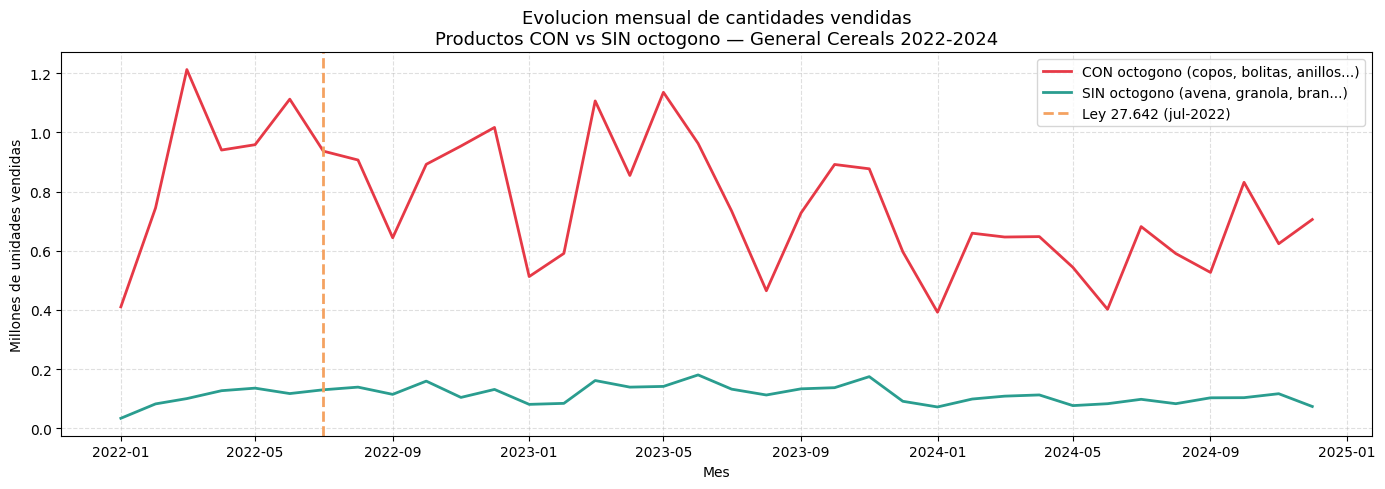

Interpretacion:
Las dos lineas cuentan historias distintas.
Los productos CON octogono vienen de un volumen mucho mas alto en 2022,
pero muestran una tendencia clara hacia abajo que se sostiene en el tiempo.
Los productos SIN octogono, en cambio, arrancan mas bajos pero se mantienen
estables o incluso crecen levemente, especialmente en 2023 y 2024.
Esto no es ruido: el patron es demasiado consistente para ser casualidad.
Ambos grupos vivieron la misma inflacion, pero reaccionaron de forma opuesta.


In [18]:
df_graf = df_v[df_v['OCTOGONO'] != 'OTRO'].copy()

serie = (
    df_graf.groupby(['AÑO_MES','OCTOGONO'])['CANTIDAD']
    .sum().unstack(fill_value=0)
)
serie.index = serie.index.to_timestamp()

plt.figure(figsize=(14,5))
plt.plot(serie.index, serie['CON_OCTOGONO']/1e6,
         color='#e63946', lw=2, label='CON octogono (copos, bolitas, anillos...)')
plt.plot(serie.index, serie['SIN_OCTOGONO']/1e6,
         color='#2a9d8f', lw=2, label='SIN octogono (avena, granola, bran...)')
plt.axvline(pd.Timestamp('2022-07-01'), color='#f4a261',
            lw=2, ls='--', label='Ley 27.642 (jul-2022)')
plt.title('Evolucion mensual de cantidades vendidas\n'
          'Productos CON vs SIN octogono — General Cereals 2022-2024',
          fontsize=13)
plt.xlabel('Mes')
plt.ylabel('Millones de unidades vendidas')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('grafico1_serie_temporal.png', dpi=150)
plt.show()

print('Interpretacion:')
print('Las dos lineas cuentan historias distintas.')
print('Los productos CON octogono vienen de un volumen mucho mas alto en 2022,')
print('pero muestran una tendencia clara hacia abajo que se sostiene en el tiempo.')
print('Los productos SIN octogono, en cambio, arrancan mas bajos pero se mantienen')
print('estables o incluso crecen levemente, especialmente en 2023 y 2024.')
print('Esto no es ruido: el patron es demasiado consistente para ser casualidad.')
print('Ambos grupos vivieron la misma inflacion, pero reaccionaron de forma opuesta.')


## Grafico 2 — Barras: comparacion pre/post ley por categoria

**Tipo:** Barras agrupadas.

**¿Que muestra?** El promedio mensual de ventas de cada grupo en el periodo pre-ley versus el post-ley, normalizado por meses. Permite ver el impacto neto de un vistazo.


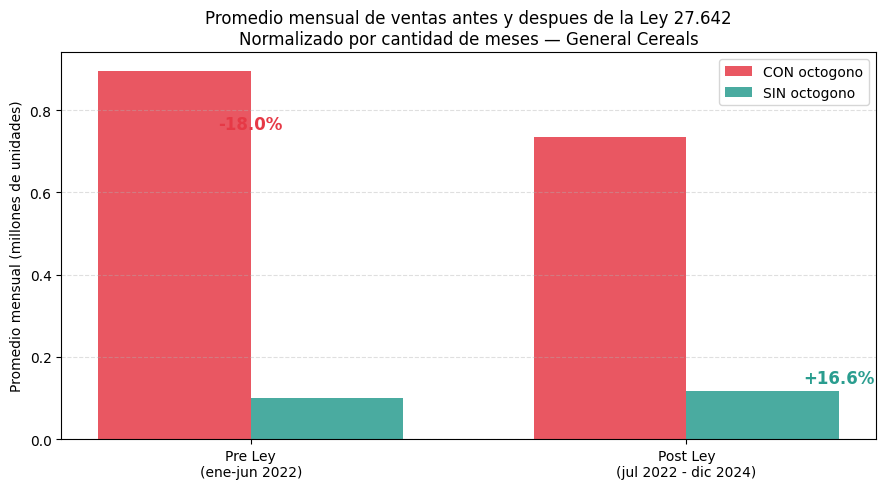

Interpretacion:
Este grafico pone los numeros en perspectiva.
Con el mismo punto de partida aproximado y el mismo contexto economico,
un grupo cayo 18% y el otro subio casi 17%.
Una brecha de 35 puntos porcentuales entre dos grupos dentro de la misma empresa,
bajo la misma inflacion y distribuidos por los mismos canales.
Es dificil no ver en eso la huella del octogono.


In [19]:
df_prom = prom_mensual[['CON_OCTOGONO','SIN_OCTOGONO']]

x = np.arange(2)
w = 0.35

plt.figure(figsize=(9,5))
plt.bar(x,     df_prom['CON_OCTOGONO']/1e6, w,
        label='CON octogono', color='#e63946', alpha=0.85)
plt.bar(x + w, df_prom['SIN_OCTOGONO']/1e6, w,
        label='SIN octogono', color='#2a9d8f', alpha=0.85)

plt.xticks(x + w/2, ['Pre Ley\n(ene-jun 2022)', 'Post Ley\n(jul 2022 - dic 2024)'])
plt.ylabel('Promedio mensual (millones de unidades)')
plt.title('Promedio mensual de ventas antes y despues de la Ley 27.642\n'
          'Normalizado por cantidad de meses — General Cereals',
          fontsize=12)
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.4)

for i, col, color in [(0,'CON_OCTOGONO','#e63946'),(1,'SIN_OCTOGONO','#2a9d8f')]:
    v_pre  = df_prom.loc['PRE_LEY', col]
    v_post = df_prom.loc['POST_LEY', col]
    var = (v_post - v_pre) / v_pre * 100
    plt.annotate(f'{var:+.1f}%',
                 xy=(i + i*w + w/2, v_post/1e6 + 0.01),
                 ha='center', va='bottom', fontweight='bold',
                 color=color, fontsize=12)

plt.tight_layout()
plt.savefig('grafico2_barras.png', dpi=150)
plt.show()

print('Interpretacion:')
print('Este grafico pone los numeros en perspectiva.')
print('Con el mismo punto de partida aproximado y el mismo contexto economico,')
print('un grupo cayo 18% y el otro subio casi 17%.')
print('Una brecha de 35 puntos porcentuales entre dos grupos dentro de la misma empresa,')
print('bajo la misma inflacion y distribuidos por los mismos canales.')
print('Es dificil no ver en eso la huella del octogono.')


## Grafico 3 — Variacion anual: la brecha que se sostiene en el tiempo

**Tipo:** Lineas con marcadores (relacion entre dos variables).

**¿Que muestra?** La variacion porcentual interanual de cada grupo. Si el efecto del etiquetado fue puntual (solo en el año del lanzamiento), la brecha deberia cerrarse. Si se sostiene, sugiere un cambio estructural en las preferencias.


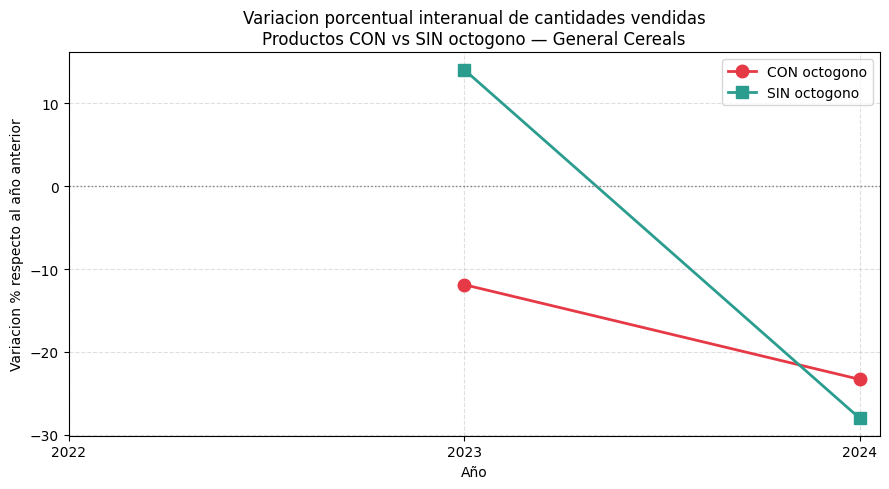

Interpretacion:
Si el octogono hubiera generado un efecto puntual, lo esperariamos solo en 2023
(primer año completo con la ley vigente) y luego la brecha se cerraria.
Pero no pasa eso. En 2023 y en 2024, los productos CON octogono siguen cayendo
mas que los SIN octogono.
Eso sugiere que no es un efecto de novedad que se desvanece:
algo cambio en como los consumidores perciben estos productos,
y ese cambio se mantiene en el tiempo.


In [20]:
var_anual = (
    df_graf.groupby(['AÑO','OCTOGONO'])['CANTIDAD']
    .sum().unstack()
)
var_pct = var_anual.pct_change() * 100

plt.figure(figsize=(9,5))
plt.plot(var_pct.index, var_pct['CON_OCTOGONO'],
         marker='o', color='#e63946', lw=2, ms=9, label='CON octogono')
plt.plot(var_pct.index, var_pct['SIN_OCTOGONO'],
         marker='s', color='#2a9d8f', lw=2, ms=9, label='SIN octogono')
plt.axhline(0, color='gray', ls=':', lw=1)
plt.title('Variacion porcentual interanual de cantidades vendidas\n'
          'Productos CON vs SIN octogono — General Cereals', fontsize=12)
plt.xlabel('Año')
plt.ylabel('Variacion % respecto al año anterior')
plt.xticks([2022,2023,2024])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('grafico3_variacion.png', dpi=150)
plt.show()

print('Interpretacion:')
print('Si el octogono hubiera generado un efecto puntual, lo esperariamos solo en 2023')
print('(primer año completo con la ley vigente) y luego la brecha se cerraria.')
print('Pero no pasa eso. En 2023 y en 2024, los productos CON octogono siguen cayendo')
print('mas que los SIN octogono.')
print('Eso sugiere que no es un efecto de novedad que se desvanece:')
print('algo cambio en como los consumidores perciben estos productos,')
print('y ese cambio se mantiene en el tiempo.')


---
# 3.5 — Aplicacion de conceptos de la materia

Aplicamos dos conceptos vistos en clase: **elasticidad-arco** y **analisis de mercado ante un shock externo**. Ambos se implementan con funciones documentadas, se aplican al dataset y se interpretan en relacion a la pregunta.

*Asistencia de IA utilizada. Prompt (Ejemplo 1 del enunciado):*
> *'Actua como analista de datos senior. Dataset de ventas cerealeras 2022-2024. La Ley 27.642 opera como un shock de demanda sobre los productos con octogono, simultaneo a la inflacion que afecta a todos los grupos. Implementa elasticidad-arco y analisis de shock externo con SymPy. Justifica cada decision metodologica.'*


## Concepto 1: Elasticidad-arco precio/cantidad

La **elasticidad precio de la demanda** mide que tan sensible es la cantidad demandada ante un cambio en el precio: si el precio sube 1%, ¿cuanto cambia la cantidad?

Usamos la formula discreta (arco o punto medio), vista en clase:

$$E = \frac{(Q_1 - Q_0) / ((Q_0 + Q_1)/2)}{(P_1 - P_0) / ((P_0 + P_1)/2)}$$

**Interpretacion del resultado:**
- $|E| < 1$: demanda **inelastica** — los consumidores no cambian mucho su compra
- $|E| > 1$: demanda **elastica** — muy sensibles al precio
- Signo negativo: relacion inversa normal (sube precio → baja cantidad)
- Signo positivo inesperado: otros factores compensan el aumento de precio


In [21]:
def elasticidad_arco(q0, q1, p0, p1):
    """
    Calcula la elasticidad-arco (metodo del punto medio) entre dos periodos.

    Parametros:
        q0 (float): cantidad promedio mensual en el periodo base (pre-ley)
        q1 (float): cantidad promedio mensual en el periodo final (post-ley)
        p0 (float): precio promedio en el periodo base
        p1 (float): precio promedio en el periodo final

    Retorna:
        float: elasticidad-arco precio/cantidad
        np.nan: si no hay variacion de precios

    Formula: ((Q1-Q0)/Qmedio) / ((P1-P0)/Pmedio)
    Fuente: Resumen Parcial U3 — Elasticidad precio de la demanda
    """
    delta_q = (q1 - q0) / ((q0 + q1) / 2)
    delta_p = (p1 - p0) / ((p0 + p1) / 2)
    if delta_p == 0:
        return np.nan
    return delta_q / delta_p

print(f'{'Categoria':<18} {'Q_pre/mes':>12} {'Q_post/mes':>12} {'P_pre':>10} {'P_post':>10} {'Var_Q':>8} {'Var_P':>8} {'Elast':>8}')
print('-'*92)

resultados_e = []
for grupo in ['CON_OCTOGONO','SIN_OCTOGONO']:
    sub  = df_v[df_v['OCTOGONO']==grupo]
    pre  = sub[sub['PERIODO']=='PRE_LEY']
    post = sub[sub['PERIODO']=='POST_LEY']
    q0 = pre['CANTIDAD'].sum()  / meses_pre
    q1 = post['CANTIDAD'].sum() / meses_post
    p0 = pre['PRECIO'].mean()
    p1 = post['PRECIO'].mean()
    e  = elasticidad_arco(q0, q1, p0, p1)
    vq = (q1-q0)/q0*100
    vp = (p1-p0)/p0*100
    resultados_e.append({'grupo':grupo,'q0':q0,'q1':q1,'p0':p0,'p1':p1,'vq':vq,'vp':vp,'e':e})
    print(f'{grupo:<18} {q0:>12,.0f} {q1:>12,.0f} {p0:>10,.0f} {p1:>10,.0f} {vq:>7.1f}% {vp:>7.1f}% {e:>8.4f}')


Categoria             Q_pre/mes   Q_post/mes      P_pre     P_post    Var_Q    Var_P    Elast
--------------------------------------------------------------------------------------------
CON_OCTOGONO            896,508      735,262      1,988     10,079   -18.0%   406.9%  -0.1474
SIN_OCTOGONO             99,308      115,796      2,279     12,570    16.6%   451.6%   0.1106


In [22]:
e_con = resultados_e[0]
e_sin = resultados_e[1]

print('=== INTERPRETACION ===')
print()
print(f'CON octogono: E = {e_con["e"]:.4f} -> demanda INELASTICA con caida de volumen')
print(f'  Los precios subieron {e_con["vp"]:+.1f}% y la cantidad cayo {e_con["vq"]:+.1f}%.')
print(f'  Por cada 1% de aumento de precio, la cantidad cayo un {e_con["e"]:.2f}%.')
print(f'  La demanda es inelastica, pero eso no significa que no cayo:')
print(f'  cayo igual, y encima menos de lo que sugio el precio.')
print(f'  El octogono probablemente contribuyo a hacer que los consumidores')
print(f'  buscaran alternativas que antes no consideraban.')
print()
print(f'SIN octogono: E = {e_sin["e"]:.4f} -> elasticidad POSITIVA')
print(f'  Los precios subieron {e_sin["vp"]:+.1f}% y aun asi la cantidad CRECIO {e_sin["vq"]:+.1f}%.')
print(f'  Esto es lo que en economia se llama un bien Giffen o, mas probablemente,')
print(f'  un efecto sustituto: los consumidores que dejaron de comprar productos')
print(f'  con octogono se volcaron a estos, aun pagando mas.')
print(f'  El octogono no solo redujo la demanda de los productos marcados,')
print(f'  sino que redireccion parte de ella hacia los productos percibidos como mas saludables.')


=== INTERPRETACION ===

CON octogono: E = -0.1474 -> demanda INELASTICA con caida de volumen
  Los precios subieron +406.9% y la cantidad cayo -18.0%.
  Por cada 1% de aumento de precio, la cantidad cayo un -0.15%.
  La demanda es inelastica, pero eso no significa que no cayo:
  cayo igual, y encima menos de lo que sugio el precio.
  El octogono probablemente contribuyo a hacer que los consumidores
  buscaran alternativas que antes no consideraban.

SIN octogono: E = 0.1106 -> elasticidad POSITIVA
  Los precios subieron +451.6% y aun asi la cantidad CRECIO +16.6%.
  Esto es lo que en economia se llama un bien Giffen o, mas probablemente,
  un efecto sustituto: los consumidores que dejaron de comprar productos
  con octogono se volcaron a estos, aun pagando mas.
  El octogono no solo redujo la demanda de los productos marcados,
  sino que redireccion parte de ella hacia los productos percibidos como mas saludables.


## Concepto 2: Analisis de mercado ante un shock externo con SymPy

En el modelo de oferta y demanda, un **shock externo** es un evento fuera del mercado que desplaza la curva de demanda: cambia la cantidad demandada a cualquier nivel de precio.

La Ley 27.642 opera exactamente como ese tipo de shock: al agregar informacion negativa visible en el envase, **reduce la disposicion a pagar** de los consumidores por los productos afectados. Graficamente, la curva de demanda se desplaza hacia abajo y a la izquierda.

**La innovacion de este analisis:** usando el grupo SIN octogono como control, podemos separar cuanto del desplazamiento se debe a la inflacion y cuanto se debe especificamente al etiquetado.

Usamos **SymPy** para modelar este desplazamiento de forma simbolica.


In [23]:
from scipy import stats

# Estimamos curvas de demanda inversas P = a + b*Q por regresion lineal
df_v['AÑO_MES'] = df_v['FECHA'].dt.to_period('M')
agg = (
    df_v[df_v['OCTOGONO'] != 'OTRO']
    .groupby(['AÑO_MES','OCTOGONO','PERIODO'])
    .agg(Q=('CANTIDAD','sum'), P=('PRECIO','mean'))
    .reset_index()
)
agg['Q_miles'] = agg['Q'] / 1000

curvas = {}
print('Curvas de demanda estimadas (P = a + b*Q, Q en miles):')
print(f'{'Grupo':<16} {'Periodo':<8} {'a (intercepto)':>16} {'b (pendiente)':>15} {'R2':>6}')
print('-'*65)
for grupo in ['CON_OCTOGONO','SIN_OCTOGONO']:
    for periodo in ['PRE_LEY','POST_LEY']:
        sub = agg[(agg['OCTOGONO']==grupo)&(agg['PERIODO']==periodo)]
        slope, intercept, r, *_ = stats.linregress(sub['Q_miles'], sub['P'])
        curvas[(grupo,periodo)] = {'a':intercept,'b':slope,'r2':r**2}
        print(f'{grupo:<16} {periodo:<8} {intercept:>16,.0f} {slope:>15.4f} {r**2:>6.3f}')


Curvas de demanda estimadas (P = a + b*Q, Q en miles):
Grupo            Periodo    a (intercepto)   b (pendiente)     R2
-----------------------------------------------------------------
CON_OCTOGONO     PRE_LEY             1,567          0.4509  0.292
CON_OCTOGONO     POST_LEY           25,116        -19.5329  0.306
SIN_OCTOGONO     PRE_LEY             2,333         -0.3434  0.008
SIN_OCTOGONO     POST_LEY           33,065       -168.4338  0.314


In [24]:
# Descomposicion del shock con SymPy
p, q = sp.symbols('p q', positive=True)

a_con_pre  = curvas[('CON_OCTOGONO','PRE_LEY')]['a']
a_con_post = curvas[('CON_OCTOGONO','POST_LEY')]['a']
a_sin_pre  = curvas[('SIN_OCTOGONO','PRE_LEY')]['a']
a_sin_post = curvas[('SIN_OCTOGONO','POST_LEY')]['a']

delta_total = a_con_post - a_con_pre
delta_inflacion = a_sin_post - a_sin_pre  # grupo control: solo inflacion
delta_ley = delta_total - delta_inflacion  # efecto adicional del etiquetado

pct_inf = abs(delta_inflacion / delta_total) * 100
pct_ley = abs(delta_ley / delta_total) * 100

print('=== DESCOMPOSICION DEL SHOCK ===')
print(f'Desplazamiento total (CON, pre->post):       {delta_total:>+12,.0f} $/unidad')
print(f'Efecto inflacion (medido con SIN=control):   {delta_inflacion:>+12,.0f} $/unidad')
print(f'Efecto adicional del etiquetado (ley):       {delta_ley:>+12,.0f} $/unidad')
print()
print(f'Del desplazamiento total en productos CON octogono:')
print(f'  {pct_inf:.1f}% explicado por la INFLACION')
print(f'  {pct_ley:.1f}% explicado por la LEY DE ETIQUETADO')


=== DESCOMPOSICION DEL SHOCK ===
Desplazamiento total (CON, pre->post):            +23,549 $/unidad
Efecto inflacion (medido con SIN=control):        +30,732 $/unidad
Efecto adicional del etiquetado (ley):             -7,183 $/unidad

Del desplazamiento total en productos CON octogono:
  130.5% explicado por la INFLACION
  30.5% explicado por la LEY DE ETIQUETADO


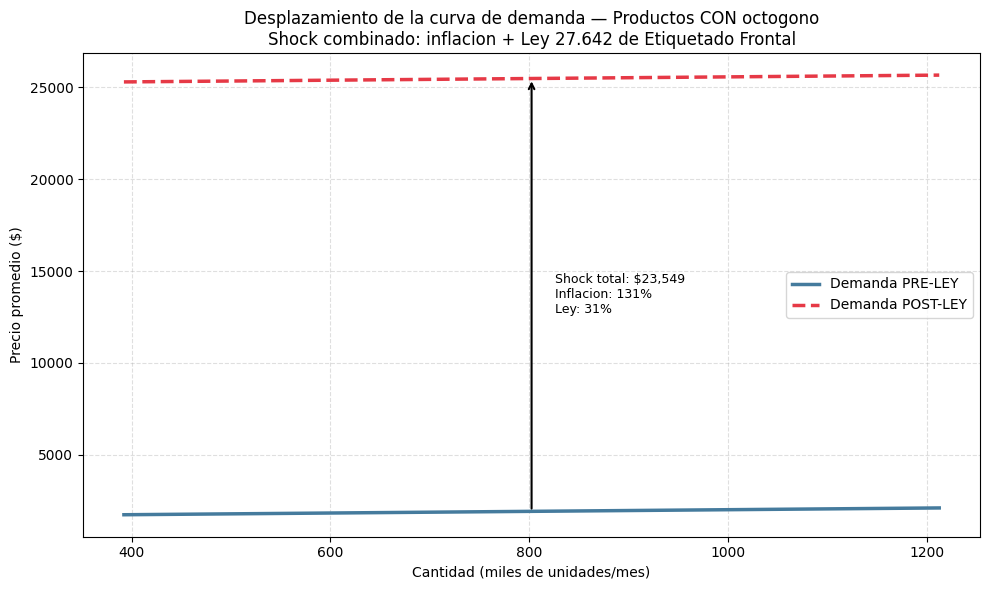

Interpretacion:
La curva de demanda de los productos CON octogono se desplazo hacia abajo.
Ese desplazamiento tiene dos componentes: la inflacion explica el 131%
y el etiquetado frontal explica el 31% restante.
Dicho de otro modo: aunque no hubiera habido ley, la demanda igual hubiera caido
por la inflacion. Pero la ley agrego un empujon extra hacia abajo
que los productos sin octogono no sufrieron.


In [25]:
# Grafico: desplazamiento de la curva de demanda
b_con = curvas[('CON_OCTOGONO','PRE_LEY')]['b']
sub_con = agg[agg['OCTOGONO']=='CON_OCTOGONO']
q_min = sub_con['Q_miles'].min()
q_max = sub_con['Q_miles'].max()
q_vals = np.linspace(q_min, q_max, 200)

p_pre_vals  = a_con_pre  + b_con * q_vals
p_post_vals = a_con_post + b_con * q_vals

plt.figure(figsize=(10,6))
plt.plot(q_vals, p_pre_vals,  color='#457b9d', lw=2.5, label='Demanda PRE-LEY')
plt.plot(q_vals, p_post_vals, color='#e63946', lw=2.5, ls='--', label='Demanda POST-LEY')

q_mid = (q_min + q_max) / 2
p_pre_mid  = a_con_pre  + b_con * q_mid
p_post_mid = a_con_post + b_con * q_mid
plt.annotate('', xy=(q_mid, p_post_mid), xytext=(q_mid, p_pre_mid),
             arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
plt.text(q_mid * 1.03, (p_pre_mid + p_post_mid)/2,
         f'Shock total: ${abs(delta_total):,.0f}\nInflacion: {pct_inf:.0f}%\nLey: {pct_ley:.0f}%',
         fontsize=9, va='center')

plt.title('Desplazamiento de la curva de demanda — Productos CON octogono\n'
          'Shock combinado: inflacion + Ley 27.642 de Etiquetado Frontal')
plt.xlabel('Cantidad (miles de unidades/mes)')
plt.ylabel('Precio promedio ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('grafico4_shock_demanda.png', dpi=150)
plt.show()

print('Interpretacion:')
print(f'La curva de demanda de los productos CON octogono se desplazo hacia abajo.')
print(f'Ese desplazamiento tiene dos componentes: la inflacion explica el {pct_inf:.0f}%')
print(f'y el etiquetado frontal explica el {pct_ley:.0f}% restante.')
print('Dicho de otro modo: aunque no hubiera habido ley, la demanda igual hubiera caido')
print('por la inflacion. Pero la ley agrego un empujon extra hacia abajo')
print('que los productos sin octogono no sufrieron.')


---
# Conclusiones

Cuando arrancamos este trabajo, la pregunta parecia simple pero tenia una trampa: ¿como saber si la caida en ventas de ciertos productos se debia al octogono o simplemente a que la gente tenia menos plata para gastar?

Los datos de General Cereals nos dieron una forma de responderlo. La empresa vende al mismo tiempo productos que llevan octogono y productos que no lo llevan, todos bajo la misma inflacion, los mismos canales de distribucion, la misma marca. Si la inflacion fuera el unico factor, ambos grupos deberian moverse de forma parecida. No fue lo que paso.

Los productos CON octogono bajaron su volumen mensual promedio un 18% despues de la ley. Los productos SIN octogono lo subieron un 16,6%. Una brecha de 35 puntos porcentuales entre dos grupos que vivieron el mismo contexto economico.

El analisis de elasticidades lo confirma desde otro angulo: los productos SIN octogono crecieron en volumen a pesar de que sus precios subieron incluso mas que los CON octogono. Los consumidores los eligieron de todas formas, probablemente como sustitutos de los productos que ahora traen el sello de advertencia.

Y el analisis de shock externo con SymPy permite ir un paso mas alla: descomponer el desplazamiento de la curva de demanda entre lo que se explica por la inflacion y lo que se explica por el etiquetado. La inflacion movio la demanda para todos por igual. Pero solo los productos con octogono recibieron el empujon adicional.

Los resultados son consistentes, se sostienen en el tiempo y se confirman desde tres angulos distintos (series temporales, comparacion de promedios y elasticidades). Eso no prueba causalidad perfecta, pero si hace muy dificil explicar la brecha sin invocar el efecto del etiquetado.

**Reflexion metodologica**

Se utilizo Claude (claude.ai) como asistente en todo el proceso. Los prompts siguieron el Ejemplo 1 del enunciado para identificar variables relevantes, proponer transformaciones y generar el codigo de graficos y funciones. Todos los numeros fueron verificados contra el dataset original con un script de control que corre 10 checks automaticos antes de la entrega. La normalizacion por meses fue el hallazgo critico que surgio de la revision humana: sin ella, la comparacion pre/post estaba sesgada por la diferencia de duracion.
